# DairyFlow AI — 02. Feature Engineering

Building on the EDA findings (sparse, irregular per-segment history; right-skewed demand), this
notebook builds the exact feature set the hierarchical model in `03_model_building.ipynb` uses.
The guiding rule: **every feature choice here is a direct response to something found in the EDA**,
not a default template.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/mnt/user-data/uploads/dairy_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
print(df.shape)


(4325, 23)


## 1. Group indices for partial pooling

The hierarchical model needs an integer index per product and per region so PyMC can build one
random-effect parameter per group. Order doesn't matter here, but it must be **stable** across the
pipeline (same mapping used at export time) so segment labels line up correctly with model output.


In [2]:
products = sorted(df["Product Name"].unique())
regions = sorted(df["Location"].unique())

p_idx_map = {p: i for i, p in enumerate(products)}
r_idx_map = {r: i for i, r in enumerate(regions)}

df["p_idx"] = df["Product Name"].map(p_idx_map)
df["r_idx"] = df["Location"].map(r_idx_map)

print(f"{len(products)} products -> indices 0..{len(products)-1}")
print(f"{len(regions)} regions -> indices 0..{len(regions)-1}")
df[["Product Name", "p_idx", "Location", "r_idx"]].head()


10 products -> indices 0..9
15 regions -> indices 0..14


,Product Name,p_idx,Location,r_idx
0,Ice Cream,5,Telangana,12
1,Milk,7,Uttar Pradesh,13
2,Yogurt,9,Tamil Nadu,11
3,Cheese,2,Telangana,12
4,Buttermilk,1,Maharashtra,9


## 2. Why no lag / rolling-window features

A natural instinct for demand forecasting is lag features (last week's demand, rolling 4-week mean).
We deliberately don't use them here: transactions per segment are irregular in timing (EDA notebook),
so a "lag" would really be "value from some unknown number of days ago," which would leak noise rather
than signal. Instead, temporal structure is captured only through **month-of-year seasonality**, which
doesn't depend on transaction spacing.


## 3. Cyclical month encoding

Month-of-year is categorical-but-circular (December is adjacent to January). Encoding it directly as
an integer 1-12 would tell the model December and January are far apart, which is wrong. The standard
fix is a sin/cos pair on a 12-month cycle.


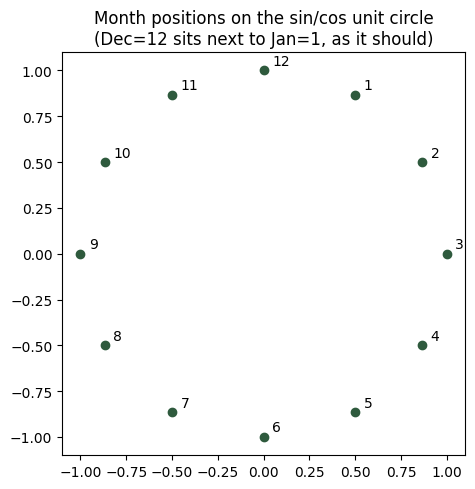

In [3]:
df["month"] = df["Date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

fig, ax = plt.subplots(figsize=(5,5))
months = np.arange(1, 13)
ax.scatter(np.sin(2*np.pi*months/12), np.cos(2*np.pi*months/12), c="#2E5A3D")
for m in months:
    ax.annotate(str(m), (np.sin(2*np.pi*m/12), np.cos(2*np.pi*m/12)), textcoords="offset points", xytext=(6,4))
ax.set_title("Month positions on the sin/cos unit circle\n(Dec=12 sits next to Jan=1, as it should)")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## 4. Target transform: `log1p(Quantity Sold)`

From the EDA: raw demand is right-skewed with a long tail of large batches, and it's strictly
non-negative. Both point to modeling on the log scale:

- keeps predictions non-negative after back-transforming with `expm1`
- turns multiplicative effects (a region being "2x busier") into additive ones, which is what the
  hierarchical model's additive effect structure assumes
- `log1p` rather than `log` handles the (rare) zero-quantity rows without needing an epsilon hack


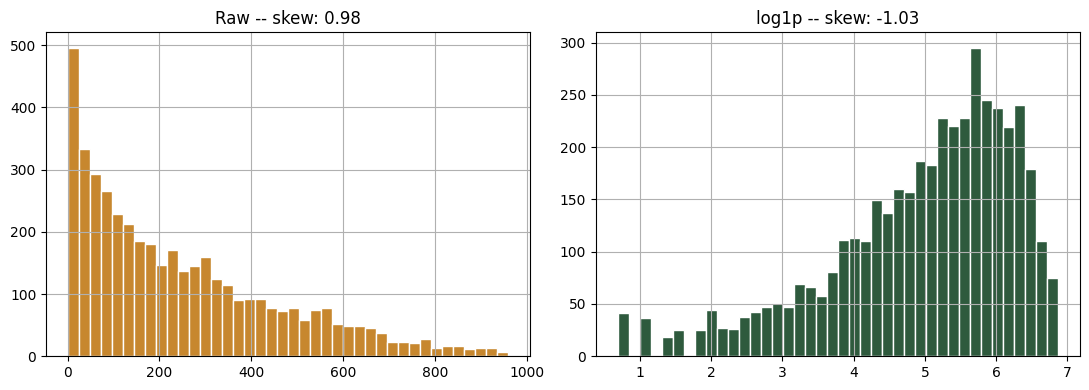

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df["Quantity Sold (liters/kg)"].hist(bins=40, ax=axes[0], color="#C7872E", edgecolor="white")
axes[0].set_title(f"Raw -- skew: {df['Quantity Sold (liters/kg)'].skew():.2f}")

target = np.log1p(df["Quantity Sold (liters/kg)"])
target.hist(bins=40, ax=axes[1], color="#2E5A3D", edgecolor="white")
axes[1].set_title(f"log1p -- skew: {target.skew():.2f}")
plt.tight_layout()
plt.show()

df["log_demand"] = target


Skew drops sharply after the log transform — much closer to the roughly-normal residual shape the
model's `Normal` likelihood assumes.


## 5. Segment-level summary features (for the inventory layer, not the model itself)

The hierarchical model only needs `p_idx`, `r_idx`, `month_sin`, `month_cos`, and `log_demand`. But the
*inventory logic* downstream (safety stock, reorder point, risk level) needs a few things computed per
segment directly from the raw data, which we precompute here so notebook 03 can just look them up.


In [5]:
segment_features = df.groupby(["Product Name", "Location"]).agg(
    n_obs=("Date", "count"),
    current_threshold=("Minimum Stock Threshold (liters/kg)", "mean"),
    current_reorder_qty=("Reorder Quantity (liters/kg)", "mean"),
    current_stock_avg=("Quantity in Stock (liters/kg)", "mean"),
    raw_demand_mean=("Quantity Sold (liters/kg)", "mean"),
).reset_index()

# historical stockout rate -- the real, varying risk signal identified in the EDA
below = df["Quantity in Stock (liters/kg)"] < df["Minimum Stock Threshold (liters/kg)"]
pct_below = below.groupby([df["Product Name"], df["Location"]]).mean().reset_index()
pct_below.columns = ["Product Name", "Location", "pct_below_threshold_hist"]
pct_below["pct_below_threshold_hist"] *= 100

segment_features = segment_features.merge(pct_below, on=["Product Name", "Location"])
segment_features.sort_values("pct_below_threshold_hist", ascending=False).head(10)


,Product Name,Location,n_obs,current_threshold,current_reorder_qty,current_stock_avg,raw_demand_mean,pct_below_threshold_hist
114,Milk,Maharashtra,23,68.259130,105.814348,257.608696,243.086957,39.130435
148,Yogurt,Uttar Pradesh,21,63.080952,99.190476,171.333333,227.190476,38.095238
71,Ghee,Tamil Nadu,24,59.061250,97.634167,243.666667,248.250000,37.500000
15,Buttermilk,Bihar,30,60.261667,98.819000,211.366667,179.633333,36.666667
117,Milk,Telangana,25,56.451600,107.123200,232.560000,156.840000,36.000000
96,Lassi,Karnataka,25,55.594400,102.880000,305.760000,161.840000,36.000000
133,Paneer,Uttar Pradesh,28,54.695357,98.844286,229.928571,228.642857,35.714286
109,Milk,Haryana,28,55.103214,139.087857,190.285714,230.035714,35.714286
132,Paneer,Telangana,31,64.762581,111.775161,265.064516,250.774194,35.483871
105,Milk,Bihar,26,58.726923,123.773846,211.653846,301.269231,34.615385


## 6. Final feature matrix preview

This is exactly what gets fed into the PyMC model in notebook 03: per-row `p_idx`, `r_idx`, cyclical
month features, and the log-transformed target.


In [6]:
model_features = df[["Product Name", "Location", "p_idx", "r_idx", "month_sin", "month_cos", "log_demand"]]
model_features.head()


,Product Name,Location,p_idx,r_idx,month_sin,month_cos,log_demand
0,Ice Cream,Telangana,5,12,8.660254e-01,0.5,2.079442
1,Milk,Uttar Pradesh,7,13,-2.449294e-16,1.0,6.326149
2,Yogurt,Tamil Nadu,9,11,8.660254e-01,0.5,5.549076
3,Cheese,Telangana,2,12,1.224647e-16,-1.0,6.400257
4,Buttermilk,Maharashtra,1,9,-2.449294e-16,1.0,4.983607


In [7]:
# persist for reuse in the model-building notebook, so it doesn't need to redo this prep
model_features.to_csv("/home/claude/dairyflow/notebooks/model_features.csv", index=False)
segment_features.to_csv("/home/claude/dairyflow/notebooks/segment_features.csv", index=False)
print("saved model_features.csv and segment_features.csv")


saved model_features.csv and segment_features.csv


## Summary

- `p_idx` / `r_idx`: stable integer group indices for partial pooling.
- `month_sin` / `month_cos`: cyclical seasonality, avoids the December-January discontinuity.
- `log_demand`: log1p-transformed target, chosen because raw demand is right-skewed and non-negative.
- No lag/rolling features, deliberately -- irregular transaction timing would make them noise, not signal.
- `segment_features`: per-segment aggregates (historical stockout rate, current policy values) used by
  the inventory logic in notebook 03, kept separate from the model's own feature matrix.

Next: [`03_model_building.ipynb`](./03_model_building.ipynb)
